In [3]:
import glob
import os
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import trackpy as tp
from sklearn.linear_model import LinearRegression

%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

pd.set_option('display.max_columns', None) # Displays all columns of df

In [2]:
# Loads tracks

tracks_path = r"/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Develop_mobility_analysis/100tp_561-100-50ms-1000g_4_conf561_merged_spots_tracks.csv"
tracks = pd.read_csv(tracks_path)
tracks.head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id
0,0,1,240.354808,700.247277,4911.314072,10202.557700,1.393954,1.229846,1323.055556,0,1.0_0.0,361
1,0,1,223.136631,708.928794,4014.206405,5122.043154,1.647806,1.314527,934.944444,1,1.0_1.0,161
2,1,1,240.641595,700.662313,4968.520453,10962.269196,1.241646,1.156954,1553.083333,0,1.0_0.0,361
3,1,1,225.587597,691.852900,3612.544331,3790.500000,2.326372,2.053595,898.027778,2,1.0_2.0,413
4,1,1,222.966845,709.648257,3948.350167,8244.582731,1.345105,1.342684,1231.333333,1,1.0_1.0,161


In [4]:
# Load all files from one folder

D21_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/Tracking/Run20231206/Link5'
D21_path = os.path.join(D21_dir,'*.csv') 
D21_files = glob.glob(D21_path)

D28_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D28/Tracking/Run20231206/Link5'
D28_path = os.path.join(D28_dir,'*.csv') 
D28_files = glob.glob(D28_path)

D35_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/Tracking/Run20231206/Link5'
D35_path = os.path.join(D35_dir,'*.csv') 
D35_files = glob.glob(D35_path)

D55_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D55/TUBB2B-KI_D55_2%/Tracking/Run20231206/Link5'
D55_path = os.path.join(D55_dir,'*.csv') 
D55_files = glob.glob(D55_path)

In [5]:
D35_files

['/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/Tracking/Run20231206/Link5/18_100tp_561-100-50ms-901g_1_conf561_spots_tracks.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/Tracking/Run20231206/Link5/6_100tp_561-100-50ms-901g_1_conf561_spots_tracks.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/Tracking/Run20231206/Link5/33_100tp_561-100-50ms-901g_1_conf561_spots_tracks.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/Tracking/Run20231206/Link5/5_100tp_561-100-50ms-901g_1_conf561_spots_tracks.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/Tracking/Run20231206/Link5/2_100tp_561-100-50ms-901g_1_conf561_spots_tracks.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/Tracking/Run20231206/Link5/37_100tp_561-100-50ms-901g_1_conf561_spots_tracks.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysi

In [6]:
# Read csv files into list

D21_all_files = []

for file in D21_files:
    table = pd.read_csv(file)
    D21_all_files.append(table)

#D21_all_files[0].head()

D28_all_files = []

for file in D28_files:
    table = pd.read_csv(file)
    D28_all_files.append(table)

#D21_all_files[0].head()

D35_all_files = []

for file in D35_files:
    table = pd.read_csv(file)
    D35_all_files.append(table)

#D21_all_files[0].head()

D55_all_files = []

for file in D55_files:
    table = pd.read_csv(file)
    D55_all_files.append(table)

D55_all_files[0].head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id
0,0,0.003922,669.220970,138.560277,1538.547137,3379.421224,3.000000,2.404281,507.194444,1,0.0039215686274509_1.0,22
1,0,0.003922,620.292477,203.320764,1501.101907,6451.198109,1.302692,1.444767,687.805556,2,0.0039215686274509_2.0,16
2,0,0.003922,489.673429,443.113483,762.022881,6310.192343,2.088058,1.863726,763.305556,3,0.0039215686274509_3.0,7
3,0,0.003922,478.366964,450.566084,2787.282372,4865.470201,1.382217,1.153637,650.416667,5,0.0039215686274509_5.0,2
4,0,0.003922,464.746104,474.741509,2235.176525,5726.910479,1.596721,1.297047,863.333333,8,0.0039215686274509_8.0,23


In [7]:
def create_unique_track_id(row: pd.Series, file_identifier: str) -> str:
    """
    Function to create unique track-ids for all tracks of all ROIs per image
    by combining roi_id, particle number, and file information.
    """
    return f"{file_identifier}_{row['roi_id']}_{row['particle']}"

In [8]:
def uniqueid(tracks):
    tracks['unique_id'] = tracks['file_roi_particle']
    track_ids = tracks['file_roi_particle'].unique()
    tracks['unique_id'] = tracks['unique_id'].replace(to_replace=track_ids, value=np.random.permutation(len(track_ids)))

    return tracks

In [9]:
def split_table_by_ROI_and_track(df):
    """
    Splits each spots file into seperate dfs by roi_id and track_id, so that spots can be sorted and filtered by frame' 
    """
    df = df.groupby(["roi_id","track_id"], sort = False, as_index = False)
    
    return df

In [19]:
def split_table_by_unique_id(df):
    """
    Splits each spots file into seperate dfs by roi_id and track_id, so that spots can be sorted and filtered by frame' 
    """
    df = df.groupby("file_roi_particle", sort = False, as_index = False)
       
    return df

In [11]:
len(D21_files)

6

In [12]:
# To merge all tracks belonging to same timepoint into one list while maintaining unique identity of every track

D21_all_files_unique = []

for i, df in enumerate(D21_all_files):

    # Apply unique track IDs using the create_track_id function
    df['file_number'] = i
    df['file_roi_particle'] = df.apply(lambda row: create_unique_track_id(row, i), axis=1)
   
    # Append the DataFrame to the list
    D21_all_files_unique.append(df)

#D21_all_files_unique[5].head()

D28_all_files_unique = []

for i, df in enumerate(D28_all_files):

    # Apply unique track IDs using the create_track_id function
    df['file_number'] = i
    df['file_roi_particle'] = df.apply(lambda row: create_unique_track_id(row, i), axis=1)
   
    # Append the DataFrame to the list
    D28_all_files_unique.append(df)

#D21_all_files_unique[6].head()

D35_all_files_unique = []

for i, df in enumerate(D35_all_files):

    # Apply unique track IDs using the create_track_id function
    df['file_number'] = i
    df['file_roi_particle'] = df.apply(lambda row: create_unique_track_id(row, i), axis=1)
   
    # Append the DataFrame to the list
    D35_all_files_unique.append(df)

#D35_all_files_unique[6].head()

D55_all_files_unique = []

for i, df in enumerate(D55_all_files):

    # Apply unique track IDs using the create_track_id function
    df['file_number'] = i
    df['file_roi_particle'] = df.apply(lambda row: create_unique_track_id(row, i), axis=1)
   
    # Append the DataFrame to the list
    D55_all_files_unique.append(df)

D55_all_files_unique[6].head()


,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id,file_number,file_roi_particle
0,0,0.003922,367.961620,373.690454,2471.967590,9247.997363,1.323489,1.348183,1258.944444,0,0.0039215686274509_0.0,0,6,6_0.0039215686274509_0
1,0,0.003922,433.450261,526.719554,1841.026055,7822.751601,1.713111,1.522613,763.777778,1,0.0039215686274509_1.0,4,6,6_0.0039215686274509_1
2,0,0.003922,437.538375,536.973063,1980.899261,9606.070829,1.527150,1.330343,1070.722222,2,0.0039215686274509_2.0,3,6,6_0.0039215686274509_2
3,0,0.003922,443.157192,550.035175,2187.215628,6892.111085,1.449599,1.365460,807.138889,3,0.0039215686274509_3.0,2,6,6_0.0039215686274509_3
4,1,0.003922,367.885398,373.461305,2654.764503,9761.288524,1.250707,1.321917,963.222222,0,0.0039215686274509_0.0,0,6,6_0.0039215686274509_0


In [20]:
# Splits tables into seperate dfs by unique_id

D21_singletracks_all = []

for tracks in D21_all_files:
    singletracks = [j for i,j in split_table_by_unique_id(tracks)]
    D21_singletracks_all.append(singletracks)

D21_singletracks_all[2][1].head()

# Splits tables into seperate dfs by unique_id

D28_singletracks_all = []

for tracks in D28_all_files:
    singletracks = [j for i,j in split_table_by_unique_id(tracks)]
    D28_singletracks_all.append(singletracks)

#D28_singletracks_all[2][1].head()

# Splits tables into seperate dfs by unique_id

D35_singletracks_all = []

for tracks in D35_all_files:
    singletracks = [j for i,j in split_table_by_unique_id(tracks)]
    D35_singletracks_all.append(singletracks)

#D35_singletracks_all[2][1].head()

# Splits tables into seperate dfs by unique_id

D55_singletracks_all = []

for tracks in D55_all_files:
    singletracks = [j for i,j in split_table_by_unique_id(tracks)]
    D55_singletracks_all.append(singletracks)

D55_singletracks_all[2][1].head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id,file_number,file_roi_particle
1,0,0.003922,571.479840,639.458423,2383.784877,4109.955432,1.366290,1.336221,521.250000,1,0.0039215686274509_1.0,8,2,2_0.0039215686274509_1
12,1,0.003922,571.230016,639.885253,2518.168769,5313.977916,1.355432,1.218613,728.861111,1,0.0039215686274509_1.0,8,2,2_0.0039215686274509_1
18,2,0.003922,571.046032,640.013866,2864.436175,3584.484837,1.380083,1.273357,636.305556,1,0.0039215686274509_1.0,8,2,2_0.0039215686274509_1
24,3,0.003922,570.473246,639.861558,2827.026416,2823.115186,1.362425,1.220936,507.333333,1,0.0039215686274509_1.0,8,2,2_0.0039215686274509_1
33,4,0.003922,570.659989,639.746440,2793.743463,3049.273485,1.268589,1.117506,651.638889,1,0.0039215686274509_1.0,8,2,2_0.0039215686274509_1


In [14]:
len(D21_singletracks_all)

6

In [21]:
# Sorts tracks by "frame" and saves all tracks in a list

D21_singletracks_all_sorted = []
        
for file in D21_singletracks_all:
    for df in file:
        df["frame"] = df["frame"].astype(int) # Is necessary for correct sorting
        df = df.sort_values(by="frame").reset_index(drop=True)
        D21_singletracks_all_sorted.append(df)

#D21_singletracks_all_sorted[0].head()

# Sorts tracks by "frame" and saves all tracks in a list

D28_singletracks_all_sorted = []
        
for file in D28_singletracks_all:
    for df in file:
        df["frame"] = df["frame"].astype(int) # Is necessary for correct sorting
        df = df.sort_values(by="frame").reset_index(drop=True)
        D28_singletracks_all_sorted.append(df)

#D28_singletracks_all_sorted[0].head()

# Sorts tracks by "frame" and saves all tracks in a list

D35_singletracks_all_sorted = []
        
for file in D35_singletracks_all:
    for df in file:
        df["frame"] = df["frame"].astype(int) # Is necessary for correct sorting
        df = df.sort_values(by="frame").reset_index(drop=True)
        D35_singletracks_all_sorted.append(df)

#D35_singletracks_all_sorted[0].head()

# Sorts tracks by "frame" and saves all tracks in a list

D55_singletracks_all_sorted = []
        
for file in D55_singletracks_all:
    for df in file:
        df["frame"] = df["frame"].astype(int) # Is necessary for correct sorting
        df = df.sort_values(by="frame").reset_index(drop=True)
        D55_singletracks_all_sorted.append(df)

D55_singletracks_all_sorted[0].head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id,file_number,file_roi_particle
0,0,0.003922,669.220970,138.560277,1.538547e+03,3379.421224,3.000000,2.404281,507.194444,1,0.0039215686274509_1.0,22,0,0_0.0039215686274509_1
1,1,0.003922,668.953068,138.794995,2.618872e+03,2643.500000,1.946415,1.573152,524.527778,1,0.0039215686274509_1.0,22,0,0_0.0039215686274509_1
2,2,0.003922,669.579014,138.289742,5.037471e-07,5362.775748,2.943880,2.814927,579.944444,1,0.0039215686274509_1.0,22,0,0_0.0039215686274509_1
3,3,0.003922,668.784194,138.839664,2.303191e+03,2941.332122,1.753562,1.640453,614.527778,1,0.0039215686274509_1.0,22,0,0_0.0039215686274509_1
4,4,0.003922,669.306528,137.944777,2.246586e+03,3227.144774,1.705499,1.615378,581.777778,1,0.0039215686274509_1.0,22,0,0_0.0039215686274509_1


In [24]:
print(type(D28_singletracks_all))
print(len(D28_singletracks_all))
print(type(D28_singletracks_all_sorted))
print(len(D55_singletracks_all_sorted))
print(type(D28_singletracks_all[0]))
print(type(D28_singletracks_all_sorted[0]))

<class 'list'>
11
<class 'list'>
155
<class 'list'>
<class 'pandas.core.frame.DataFrame'>


In [29]:
# Concatenates all tracks belonging to one timepoint into one dataframe

D21_all_tracks = pd.concat(D21_singletracks_all_sorted)
print(type(D21_all_tracks))

D28_all_tracks = pd.concat(D28_singletracks_all_sorted)
print(type(D21_all_tracks))

D35_all_tracks = pd.concat(D35_singletracks_all_sorted)
print(type(D21_all_tracks))

D55_all_tracks = pd.concat(D55_singletracks_all_sorted)
print(type(D21_all_tracks))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [30]:
# Applies uniqueid function to asign a unique integer to each track

D21_all_tracks = uniqueid(D21_all_tracks)
D28_all_tracks = uniqueid(D28_all_tracks)
D35_all_tracks = uniqueid(D35_all_tracks)
D55_all_tracks = uniqueid(D55_all_tracks)

In [31]:
D21_all_tracks.head(30)

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id,file_number,file_roi_particle
0,0,0.003922,276.271508,597.048271,6339.789603,7239.672343,1.137515,1.411610,1157.361111,3,0.0039215686274509_3.0,1019,0,0_0.0039215686274509_3
1,1,0.003922,275.696882,596.167325,6211.456683,6869.433794,1.602929,1.197788,1320.638889,3,0.0039215686274509_3.0,1019,0,0_0.0039215686274509_3
2,2,0.003922,275.769939,594.720288,5623.935546,8422.680870,1.481859,1.549476,1345.222222,3,0.0039215686274509_3.0,1019,0,0_0.0039215686274509_3
3,3,0.003922,273.898536,594.424059,4518.828709,5439.851297,2.336533,2.097204,1122.527778,3,0.0039215686274509_3.0,1019,0,0_0.0039215686274509_3
4,4,0.003922,273.704108,595.143241,5181.340722,6703.632514,1.802514,1.446034,1220.527778,3,0.0039215686274509_3.0,1019,0,0_0.0039215686274509_3
5,5,0.003922,277.195252,595.895696,4930.014329,5270.348597,1.484796,1.997005,1129.444444,3,0.0039215686274509_3.0,1019,0,0_0.0039215686274509_3
6,6,0.003922,273.547408,594.409025,4492.754785,5969.787373,1.451987,1.444677,1065.833333,3,0.0039215686274509_3.0,1019,0,0_0.0039215686274509_3
7,7,0.003922,274.842489,593.673673,4827.343603,4951.562256,1.283868,1.262323,1013.944444,3,0.0039215686274509_3.0,1019,0,0_0.0039215686274509_3
8,8,0.003922,273.316969,594.299715,4655.359948,4475.500000,1.450427,1.573418,863.833333,3,0.0039215686274509_3.0,1019,0,0_0.0039215686274509_3
9,9,0.003922,273.347023,594.298299,4602.203870,4368.000000,1.520826,1.607276,859.083333,3,0.0039215686274509_3.0,1019,0,0_0.0039215686274509_3


In [120]:
# Defines function to calculate time-averaged MSD(tamsd) for a single track in a given ROI

def calculate_single_tamsd(
    single_traj: pd.DataFrame, min_length: int = 5, min_points: int = 1
):
    """Calculates time-averaged MSDs of one track in a given ROI.
    
    Inputs: 
        df containing coordintes of one trajectory in an ROI, sorted by frame.
        min_length: minimum length of trajectory.
        min_points: minimum number of points to consider to calculate tamsd.
        
    Return:
        results: pd.DataFrame containing lags and time-averaged MSDs of a given track.
    """
    
    # Calculates pair-wise differences between all timepoints in the trajectory and stores it in a matrix
    tvalues = single_traj["frame"].values
    tvalues = tvalues[:, None] - tvalues
  
    # List of lags
    lags = np.arange(len(single_traj)) + 1
    
    final_lags = []
    tamsd = []
    
    # Loop over lags
    for lag in lags:
        # Find indices of pairs of timepoints with lag equal to the selected lag
        x,y = np.where(tvalues == lag)
        
        single_traj["x"] = single_traj["x"].astype(float)
        single_traj["y"] = single_traj["y"].astype(float)
        
        if len(single_traj) < min_length:
            continue
        
        if len(x) < min_points:
            continue
        
        tmp_tamsd = np.mean(
            
                np.square(
                single_traj.iloc[x][["x","y"]].values
                -single_traj.iloc[y][["x","y"]].values
                )
            
        )
        
        final_lags.append(lag)
        tamsd.append(tmp_tamsd)
    
    df = pd.DataFrame({"lags": final_lags, "tamsd": tamsd})
    
    return df    

In [121]:
# Calculates time-averaged MSD(tamsd) for a single track in a given ROI

D21_tamsd_singletrack = calculate_single_tamsd(D21_singletracks_all_sorted[5])
print(D21_tamsd_singletrack)

    lags      tamsd
0      1   1.654434
1      2   3.528176
2      3   5.395834
3      4   6.604096
4      5   7.654726
5      6   9.492258
6      7  11.285022
7      8  12.751763
8      9  14.166878
9     10  15.861302
10    11  16.728588
11    12  17.675526
12    13  18.443297
13    14  19.318212
14    15  19.987610
15    16  19.970859
16    17  20.534892
17    18  22.062650
18    19  21.373827
19    20  19.102894
20    21  15.142176
21    22  12.463425
22    23  10.388511
23    24   9.305140
24    25   8.966280
25    26   6.764742
26    27   4.360478
27    28   3.279707
28    29   2.944868
29    30   3.793250
30    31   3.304343
31    32   3.387082
32    33   4.709296
33    34   5.413887
34    35   5.528479
35    36   5.465588


To get correct amount of lags, +1 needs to be added to the np.arange(len(single_traj)), otherwise the first lag would be 0. 
Specific example where one track contains 24 time points: The tvalues, meaning the differences between time points, range from +/- 1 to +/- 23, excluding (!) the value 24. Therefore when finding values where tvalues == lags, the value 24, which is an artifact of the len(single_traj) calculation, is excluded and the remaining values range from 1 to 23, which corresponds exactly to the amount of lags present.

In [122]:
# Calculates the tamsd for all tracks seperately and saves them in a list

D21_tamsd_seperate_tracks = []

for track in D21_singletracks_all_sorted:
    tamsd = calculate_single_tamsd(track)
    D21_tamsd_seperate_tracks.append(tamsd)

print(D21_tamsd_seperate_tracks[5])

D28_tamsd_seperate_tracks = []

for track in D28_singletracks_all_sorted:
    tamsd = calculate_single_tamsd(track)
    D28_tamsd_seperate_tracks.append(tamsd)

print(D28_tamsd_seperate_tracks[5])

D35_tamsd_seperate_tracks = []

for track in D35_singletracks_all_sorted:
    tamsd = calculate_single_tamsd(track)
    D35_tamsd_seperate_tracks.append(tamsd)

print(D35_tamsd_seperate_tracks[5])

D55_tamsd_seperate_tracks = []

for track in D55_singletracks_all_sorted:
    tamsd = calculate_single_tamsd(track)
    D55_tamsd_seperate_tracks.append(tamsd)

print(D55_tamsd_seperate_tracks[5])

    lags      tamsd
0      1   1.654434
1      2   3.528176
2      3   5.395834
3      4   6.604096
4      5   7.654726
5      6   9.492258
6      7  11.285022
7      8  12.751763
8      9  14.166878
9     10  15.861302
10    11  16.728588
11    12  17.675526
12    13  18.443297
13    14  19.318212
14    15  19.987610
15    16  19.970859
16    17  20.534892
17    18  22.062650
18    19  21.373827
19    20  19.102894
20    21  15.142176
21    22  12.463425
22    23  10.388511
23    24   9.305140
24    25   8.966280
25    26   6.764742
26    27   4.360478
27    28   3.279707
28    29   2.944868
29    30   3.793250
30    31   3.304343
31    32   3.387082
32    33   4.709296
33    34   5.413887
34    35   5.528479
35    36   5.465588
   lags     tamsd
0     1  0.336096
1     2  0.583082
2     3  0.020127
3     4  0.056896
4     5  0.174483
5     6  0.738943
   lags     tamsd
0     2  0.003276
1     3  0.291036
2     4  0.055544
3     5  0.205432
   lags     tamsd
0     1  1.217577
1     2 

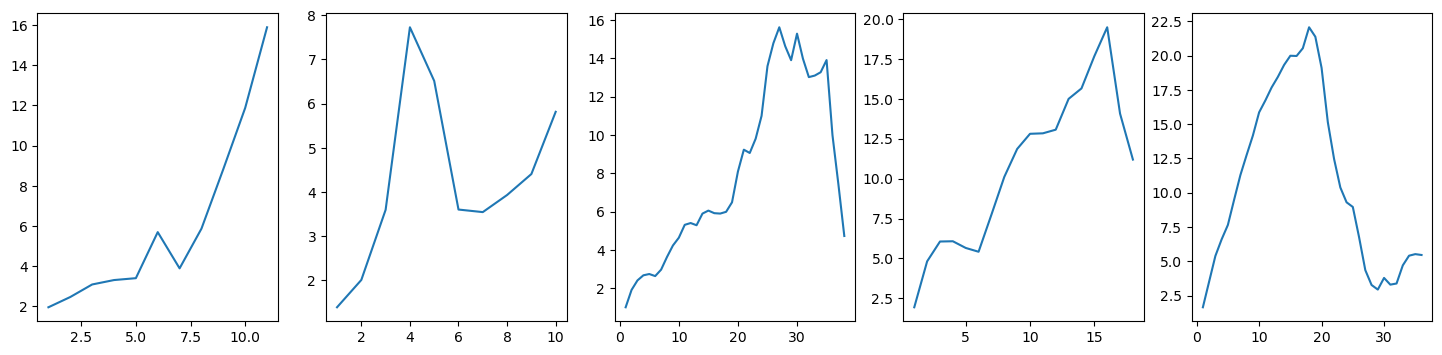

In [123]:
fig, ax = plt.subplots(1,5, figsize= (18,4))
ax[0].plot(D21_tamsd_seperate_tracks[0]["lags"],D21_tamsd_seperate_tracks[0]["tamsd"])
ax[1].plot(D21_tamsd_seperate_tracks[1]["lags"],D21_tamsd_seperate_tracks[1]["tamsd"])
ax[2].plot(D21_tamsd_seperate_tracks[2]["lags"],D21_tamsd_seperate_tracks[2]["tamsd"])
ax[3].plot(D21_tamsd_seperate_tracks[4]["lags"],D21_tamsd_seperate_tracks[4]["tamsd"])
ax[4].plot(D21_tamsd_seperate_tracks[5]["lags"],D21_tamsd_seperate_tracks[5]["tamsd"])

In [124]:
print(D21_tamsd_seperate_tracks[3])

   lags     tamsd
0     1  0.458933
1     2  0.784226
2     3  0.495872
3     4  0.481098
4     5  0.545430
5     6  0.933918
6     7  0.787222
7     8  1.626950
8     9  2.735111


In [125]:
# Calculates time-averaged MSD (tamsd) for a all tracks in a given ROI

def calculate_all_tamsd(
    all_traj: pd.DataFrame, min_points: int = 1, min_length: int = 5, radial: bool = False
):
    """Calculates time-averaged MSDs of all tracks in a given ROI.
    
    Inputs: 
        df containing coordintes of every trajectory in an ROI, sorted by "frame".
        min_points: minimum number of points to consider time-averaged MSD.
        min_length: minimum length of trajectory accepted.
        
    Return:
        results: pd.DataFrame containing all time-averaged MSDs of a give ROI.
    """
    
    # Output results
    results = pd.DataFrame()
    
    # Loop for all tracks
    for track_id in all_traj["unique_id"].unique():
        
        # Extract single trajectories and sort by frame
        single_traj = all_traj[all_traj["unique_id"] == track_id].copy().sort_values(by="frame")
        
        # Filter out short tracks
        if len(single_traj) < min_length:
            continue
            
        df_tmp = calculate_single_tamsd(
            single_traj, min_points = min_points
        )
        df_tmp["track_id"] = track_id
        results = pd.concat([results, df_tmp])
        
    return results

In [126]:
# Calculates time-averaged MSD(tamsd) for all tracks

tamsd_D21_all_tracks = calculate_all_tamsd(D21_all_tracks)
#tamsd_D21_all_tracks.head()

tamsd_D28_all_tracks = calculate_all_tamsd(D28_all_tracks)
#tamsd_D28_all_tracks.head()

tamsd_D35_all_tracks = calculate_all_tamsd(D35_all_tracks)
tamsd_D35_all_tracks.head()

tamsd_D55_all_tracks = calculate_all_tamsd(D55_all_tracks)
#tamsd_D55_all_tracks.head()

In [127]:
print(len(tamsd_D21_all_tracks['track_id'].unique()))
print(len(D21_all_tracks['unique_id'].unique()))

1010
1176


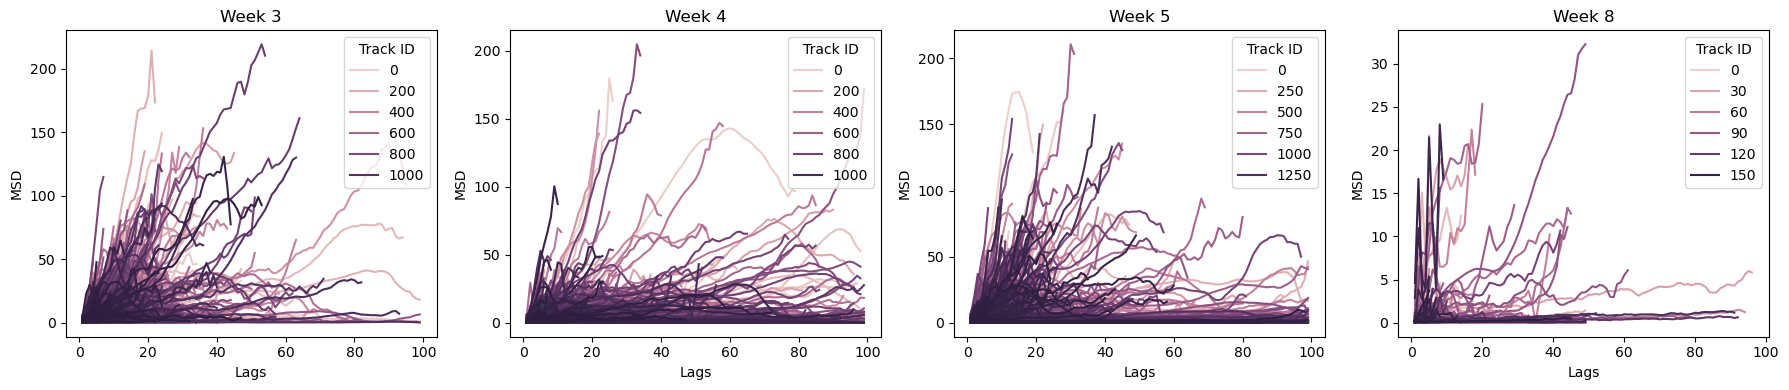

In [128]:
# Plots tamsds of all tracks

plt.figure(figsize=(18, 4))

plt.subplot(1, 4, 1)
sns.lineplot(x="lags", y="tamsd",
             hue="track_id",
             data=tamsd_D21_all_tracks)
plt.xlabel('Lags')
plt.ylabel('MSD')
plt.legend(loc='upper right', title='Track ID')
plt.title('Week 3')

plt.subplot(1, 4, 2)
sns.lineplot(x="lags", y="tamsd",
             hue="track_id",
             data=tamsd_D28_all_tracks)
plt.xlabel('Lags')
plt.ylabel('MSD')
plt.legend(loc='upper right', title='Track ID')
plt.title('Week 4')

plt.subplot(1, 4, 3)
sns.lineplot(x="lags", y="tamsd",
             hue="track_id",
             data=tamsd_D35_all_tracks)
plt.xlabel('Lags')
plt.ylabel('MSD')
plt.legend(loc='upper right', title='Track ID')
plt.title('Week 5')

plt.subplot(1, 4, 4)
sns.lineplot(x="lags", y="tamsd",
             hue="track_id",
             data=tamsd_D55_all_tracks)
plt.xlabel('Lags')
plt.ylabel('MSD')
plt.legend(loc='upper right', title='Track ID')
plt.title('Week 8')

plt.tight_layout()
plt.show()


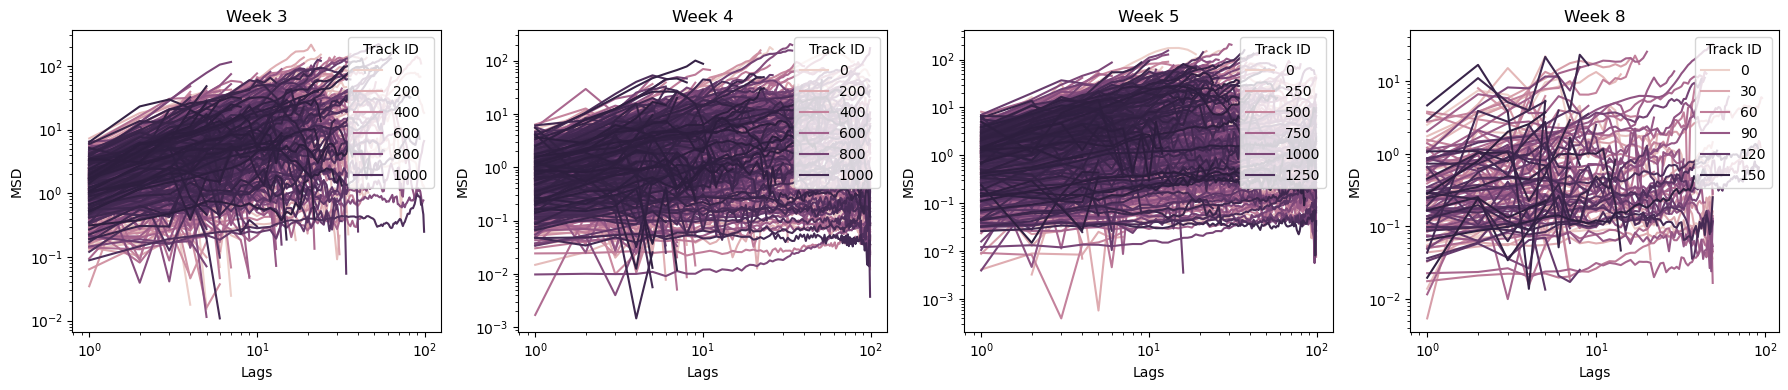

In [129]:
# Plots tamsds of all ROIs in log/log

plt.figure(figsize=(18, 4))

plt.subplot(1, 4, 1)
sns.lineplot(x="lags", y="tamsd",
             hue="track_id",
             data=tamsd_D21_all_tracks)
plt.yscale("log")
plt.xscale("log")
plt.xlabel('Lags')
plt.ylabel('MSD')
plt.legend(loc='upper right', title='Track ID')
plt.title('Week 3')

plt.subplot(1, 4, 2)
sns.lineplot(x="lags", y="tamsd",
             hue="track_id",
             data=tamsd_D28_all_tracks)
plt.yscale("log")
plt.xscale("log")
plt.xlabel('Lags')
plt.ylabel('MSD')
plt.legend(loc='upper right', title='Track ID')
plt.title('Week 4')

plt.subplot(1, 4, 3)
sns.lineplot(x="lags", y="tamsd",
             hue="track_id",
             data=tamsd_D35_all_tracks)
plt.yscale("log")
plt.xscale("log")
plt.xlabel('Lags')
plt.ylabel('MSD')
plt.legend(loc='upper right', title='Track ID')
plt.title('Week 5')

plt.subplot(1, 4, 4)
sns.lineplot(x="lags", y="tamsd",
             hue="track_id",
             data=tamsd_D55_all_tracks)
plt.yscale("log")
plt.xscale("log")
plt.xlabel('Lags')
plt.ylabel('MSD')
plt.legend(loc='upper right', title='Track ID')
plt.title('Week 8')

plt.tight_layout()
plt.show()

In [49]:
len(D21_all_tracks["unique_id"].unique())

1176

## Plot distributions of D (inst. diffusion coefficient) and alpha (slope, anomalous exponent)

Here I do a linear fit on the single MSDs for each trajectory based on the initial 5 points (numPoints) of the MSD for each trajectory (in log, log). So then the slope of the fitted curve is the anomalous exponent and the intersect can be interpreted as the instantaneiys diffusion coefficient (under some circumstances). Ask physicists ;)

In [130]:
# To do a linear fit on the log(dt), log(MSD) curve and define alpha and D

def get_D_alpha(traj, min_length=5, numPoints=5):
    if traj.shape[0]<min_length:
        return np.nan, np.nan
    model = LinearRegression()
    x = np.log10(traj.loc[:, "lags"])
    y = np.log10(traj.loc[:, "tamsd"])
    #print(x.to_numpy().reshape(-1,1)[:numPoints], y.to_numpy()[:numPoints], sampleWeight.to_numpy()[:numPoints])
    model.fit(x.to_numpy().reshape(-1,1)[:numPoints], y.to_numpy()[:numPoints])
    return model.intercept_.round(4), model.coef_.round(4)[0]

In [134]:
# Calculate D and alpha for all tracks seperately

D21_D_alpha_rows = []

for track in D21_tamsd_seperate_tracks:
    D, alpha = get_D_alpha(track)
    D21_D_alpha_rows.append({"D": D, "alpha": alpha})

D21_D_alpha_alltracks = pd.DataFrame(D21_D_alpha_rows)

#print(D21_D_alpha_alltracks)

D28_D_alpha_rows = []

for track in D28_tamsd_seperate_tracks:
    D, alpha = get_D_alpha(track)
    D28_D_alpha_rows.append({"D": D, "alpha": alpha})

D28_D_alpha_alltracks = pd.DataFrame(D28_D_alpha_rows)

#print(D28_D_alpha_alltracks)

D35_D_alpha_rows = []

for track in D35_tamsd_seperate_tracks:
    D, alpha = get_D_alpha(track)
    D35_D_alpha_rows.append({"D": D, "alpha": alpha})

D35_D_alpha_alltracks = pd.DataFrame(D35_D_alpha_rows)

#print(D35_D_alpha_alltracks)

D55_D_alpha_rows = []

for track in D55_tamsd_seperate_tracks:
    D, alpha = get_D_alpha(track)
    D55_D_alpha_rows.append({"D": D, "alpha": alpha})

D55_D_alpha_alltracks = pd.DataFrame(D55_D_alpha_rows)

print(D21_D_alpha_alltracks)

           D   alpha
0     0.2942  0.3645
1     0.0834  1.1005
2     0.0414  0.6362
3    -0.2664  0.0013
4     0.3737  0.6843
...      ...     ...
1171  0.1093  1.1411
1172 -0.1183  0.1768
1173  0.1767  0.9695
1174  0.3124  0.6506
1175  0.0212  0.7070

[1176 rows x 2 columns]


In [97]:
type(D55_D_alpha_alltracks)

pandas.core.frame.DataFrame

In [135]:
# To remove all nan values from table

D21_D_alpha_alltracks_filtered = D21_D_alpha_alltracks.dropna(how='all')
print(D21_D_alpha_alltracks_filtered)

D28_D_alpha_alltracks_filtered = D28_D_alpha_alltracks.dropna(how='all')
#print(D28_D_alpha_alltracks_filtered)

D35_D_alpha_alltracks_filtered = D35_D_alpha_alltracks.dropna(how='all')
#print(D35_D_alpha_alltracks_filtered)

D55_D_alpha_alltracks_filtered = D55_D_alpha_alltracks.dropna(how='all')
#print(D55_D_alpha_alltracks_filtered)

           D   alpha
0     0.2942  0.3645
1     0.0834  1.1005
2     0.0414  0.6362
3    -0.2664  0.0013
4     0.3737  0.6843
...      ...     ...
1171  0.1093  1.1411
1172 -0.1183  0.1768
1173  0.1767  0.9695
1174  0.3124  0.6506
1175  0.0212  0.7070

[947 rows x 2 columns]


In [100]:
D21_D_alpha_alltracks_filtered.head()

,D,alpha
0,0.2942,0.3645
1,0.0834,1.1005
2,0.0414,0.6362
4,0.3737,0.6843
5,0.2391,0.9649


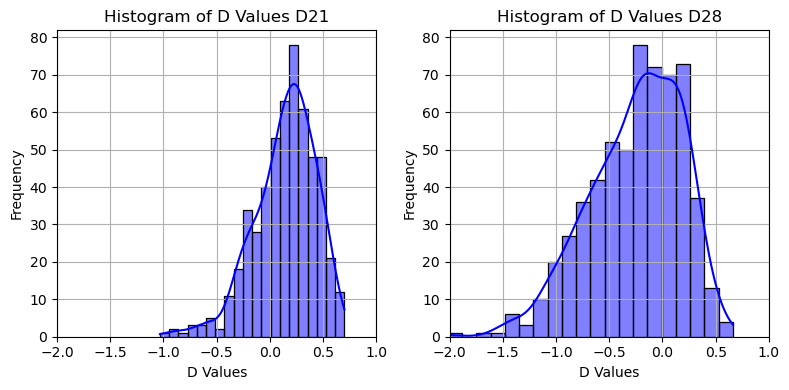

In [75]:
# Plot histogram for 'D'

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=D21_D_alpha_alltracks_filtered['D'].dropna(), bins=20, color='blue', kde=True)
plt.xlabel('D Values')
plt.xlim(-2,1)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.ylabel('Frequency')
plt.title('Histogram of D Values D21')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(data=D28_D_alpha_alltracks_filtered['D'].dropna(), bins=20, color='blue', kde=True)
plt.xlim(-2,1)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.xlabel('D Values')
plt.ylabel('Frequency')
plt.title('Histogram of D Values D28')
plt.grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

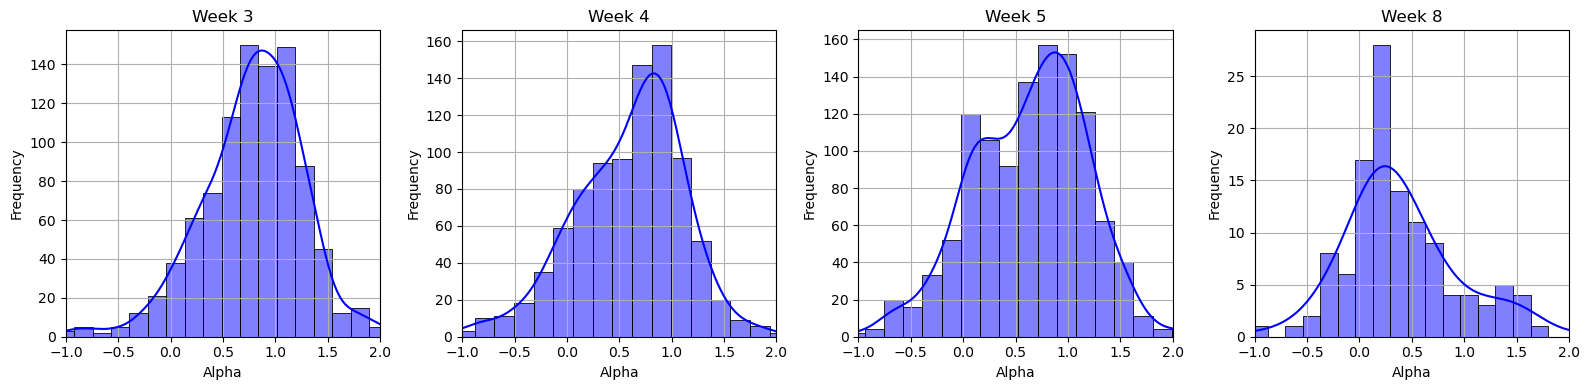

In [145]:
# Plot histogram for 'alpha'

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
sns.histplot(data=D21_D_alpha_alltracks_filtered['alpha'].dropna(), bins=30, color='blue', kde=True)
plt.xlabel('Alpha')
plt.xlim(-1,2)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.ylabel('Frequency')
plt.title('Week 3')
plt.grid(True)

plt.subplot(1, 4, 2)
sns.histplot(data=D28_D_alpha_alltracks_filtered['alpha'].dropna(), bins=30, color='blue', kde=True)
plt.xlim(-1,2)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.xlabel('Alpha')
plt.ylabel('Frequency')
plt.title('Week 4')
plt.grid(True)

plt.subplot(1, 4, 3)
sns.histplot(data=D35_D_alpha_alltracks_filtered['alpha'].dropna(), bins=30, color='blue', kde=True)
plt.xlabel('Alpha')
plt.xlim(-1,2)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.ylabel('Frequency')
plt.title('Week 5')
plt.grid(True)

plt.subplot(1, 4, 4)
sns.histplot(data=D55_D_alpha_alltracks_filtered['alpha'].dropna(), bins=30, color='blue', kde=True)
plt.xlim(-1,2)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.xlabel('Alpha')
plt.ylabel('Frequency')
plt.title('Week 8')
plt.grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

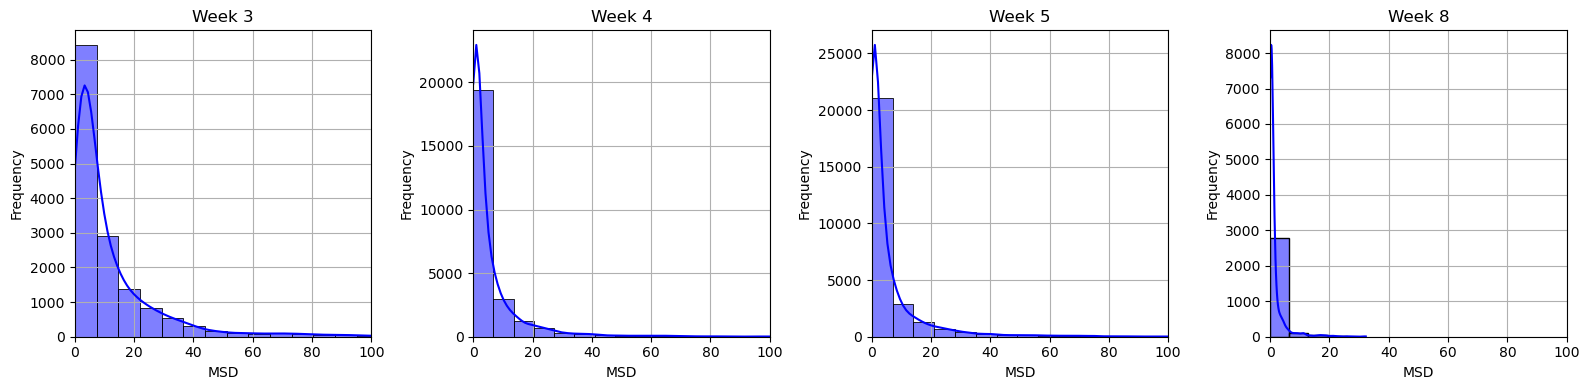

In [160]:
# Plot histogram for 'MSD'

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
sns.histplot(data=tamsd_D21_all_tracks['tamsd'], bins=30, color='blue', kde=True)
plt.xlabel('MSD')
plt.xlim(0,100)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.ylabel('Frequency')
plt.title('Week 3')
plt.grid(True)

plt.subplot(1, 4, 2)
sns.histplot(data=tamsd_D28_all_tracks['tamsd'], bins=30, color='blue', kde=True)
plt.xlim(0,100)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.xlabel('MSD')
plt.ylabel('Frequency')
plt.title('Week 4')
plt.grid(True)

plt.subplot(1, 4, 3)
sns.histplot(data=tamsd_D35_all_tracks['tamsd'], bins=30, color='blue', kde=True)
plt.xlabel('MSD')
plt.xlim(0,100)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.ylabel('Frequency')
plt.title('Week 5')
plt.grid(True)

plt.subplot(1, 4, 4)
sns.histplot(data=tamsd_D55_all_tracks['tamsd'], bins=5, color='blue', kde=True)
plt.xlim(0,100)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.xlabel('MSD')
plt.ylabel('Frequency')
plt.title('Week 8')
plt.grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [161]:
len(tamsd_D21_all_tracks)

15210

In [149]:
# Dataframe containing the number of tracks per time point

data_no_tracks = {'Week': [3, 4, 5, 8], 
     'Number of tracks': [len(D21_D_alpha_alltracks_filtered), len(D28_D_alpha_alltracks_filtered), len(D35_D_alpha_alltracks_filtered), len(D55_D_alpha_alltracks_filtered)]
     }
number_of_tracks = pd.DataFrame(data=data_no_tracks)

In [150]:
number_of_tracks

,Week,Number of tracks
0,3,947
1,4,912
2,5,1146
3,8,122


In [147]:
from pathlib import Path  
filepath = Path('/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Plots/no_tracks.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
number_of_tracks.to_csv(filepath)

In [ ]:
# TO DOs

# Plot data in different ways - scatterplot, split up by ROIs, mean values
# Plot spread of single squared displacements
# Plot MSDs (as histogram, for each jump?)
# Calculate and plot (instantaneous) diffusion coefficients

# Calculate jumps

Here I take all the long trajectories (can be set to desired length in the previous section) and calculate all the jumps (so distances travelled for a specific dt) and plot the boxplots for all found displacement given a certain dt. You could also do distributions for each dt (I gave it a try).

In [82]:
singletracks_sorted[5].head(20)

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id
0,6,1,237.309924,702.166670,3221.557168,3394.000000,2.376835,2.397742,726.194444,6,1.0_6.0,51
1,8,1,239.088044,700.076245,3555.952169,3603.000000,1.894338,3.000000,792.194444,6,1.0_6.0,51
2,9,1,240.047145,698.638488,3729.735975,3853.969940,1.806374,2.245079,912.555556,6,1.0_6.0,51
3,10,1,239.793678,697.949750,2460.830847,4291.945231,2.546687,2.460488,790.416667,6,1.0_6.0,51
4,11,1,239.141818,695.242604,3246.109242,3394.000000,1.813642,1.708155,733.166667,6,1.0_6.0,51
5,12,1,239.395250,695.242520,3642.135332,3663.000000,1.870102,1.543405,762.805556,6,1.0_6.0,51
6,13,1,238.754871,696.468068,3658.767340,3629.500000,1.843813,1.761709,850.111111,6,1.0_6.0,51
7,14,1,238.847329,697.684833,3636.201869,3862.638129,2.199369,1.694802,827.138889,6,1.0_6.0,51
8,15,1,238.614839,695.632937,3639.486024,4016.518260,1.653177,1.403643,820.083333,6,1.0_6.0,51
9,16,1,238.738875,696.761178,3139.565219,3888.279185,1.946076,1.627567,824.583333,6,1.0_6.0,51


In [79]:
# Calculate single jumps from the trajectories

def calculate_jump(single_traj, axis=None):
    jumps = []
    
    tvalues = single_traj["frame"].values
    tvalues = tvalues[:, None] - tvalues

    # list of lags
    lags = np.arange(10,100,10)


    # Loop over lags
    for lag in lags:
        # find indexes of pairs of timepoints with lag equal to the selected lag
        x, y = np.where(tvalues == lag)
                
        if axis is None:
            tmp = pd.DataFrame({"jumps":np.sum(
                    np.square(
                        single_traj.iloc[x][["x", "y"]].values
                        - single_traj.iloc[y][["x", "y"]].values
                    ),
                    axis=1,
                ), "frame":single_traj.iloc[y]["frame"].values})
        elif axis in ["x", "y"]:
            tmp = pd.DataFrame({"jumps":single_traj.iloc[x][axis].values - single_traj.iloc[y][axis].values, 
                                    "frame":single_traj.iloc[y]["frame"].values})
        else:
            raise ValueError(f"axis must be in ['x', 'y'] or none, but provided {axis}")
                            
        #tmp = pd.DataFrame(tmp_jumps)
        #tmp.columns = ["jumps"]
        tmp["deltat"] = lag
        jumps.append(tmp)


    return pd.concat(jumps)

In [80]:
jumps = calculate_jump(single_traj=singletracks_sorted[5])
jumps

,jumps,frame,deltat
0,31.261247,6,10
1,3.177242,8,10
2,3.324287,9,10
3,0.186307,10,10
4,1.779448,11,10
5,5.284105,12,10
6,1.440077,13,10
7,4.862657,14,10
8,3.470116,15,10
9,3.001801,16,10


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


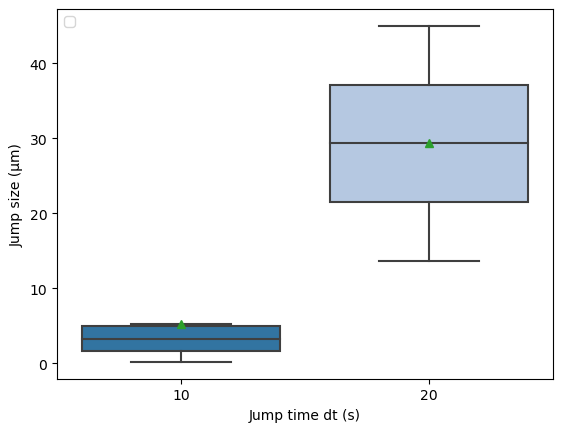

In [84]:
sns.boxplot(data=jumps, x="deltat", y="jumps", fliersize=0, palette="tab20",showmeans=True)
plt.xlabel("Jump time dt (s)")
plt.ylabel("Jump size (µm)")
plt.legend(loc="upper left")
plt.show()

### Comparing msd function to trackpy function

In [19]:
# MSD function from trackpy comparison

tp_imsd = tp.imsd(singletracks[5], 0.134, 20)
tp_imsd

,6
lag time [s],
0.05,0.032259
0.10,0.061339
0.15,0.091260
0.20,0.093581
0.25,0.128720
0.30,0.132032
0.35,0.136160
0.40,0.111112
0.45,0.126988


<Axes: xlabel='lags', ylabel='tamsd'>

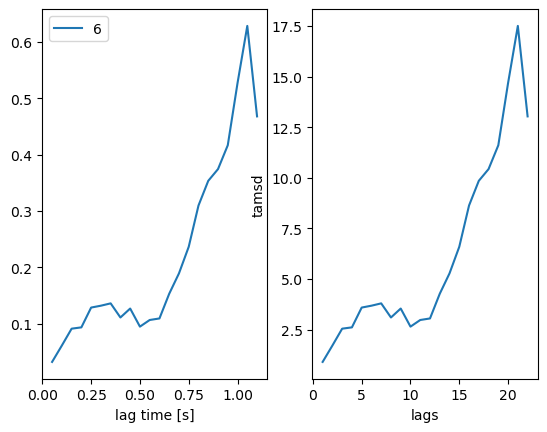

In [20]:
# Compares trackpy's MSD function with Pia's - they do the same
fig, ax = plt.subplots(1,2)
sns.lineplot(data=tp_imsd, ax=ax[0])
sns.lineplot(x="lags", y="tamsd", data=tamsd_singletrack, ax=ax[1])